In [2]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import types
from datasets import load_dataset, Dataset, DatasetDict
from collections import Counter

In [3]:
base_path = "/kaggle/input/datasets/muanaikhalifah/indosum/"

train_files = sorted(glob.glob(base_path + "train*.jsonl"))
val_files   = sorted(glob.glob(base_path + "dev*.jsonl")) 
test_files  = sorted(glob.glob(base_path + "test*.jsonl"))

print(f"Ditemukan: {len(train_files)} file train, {len(val_files)} file validation, {len(test_files)} file test.")

data_files = {
    "train": train_files,
    "validation": val_files,
    "test": test_files
}

dataset = load_dataset("json", data_files=data_files)

print("Dataset succesfully loaded!")
print(dataset)

Ditemukan: 5 file train, 5 file validation, 5 file test.


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Dataset succesfully loaded!
DatasetDict({
    train: Dataset({
        features: ['category', 'gold_labels', 'id', 'paragraphs', 'source', 'source_url', 'summary'],
        num_rows: 71353
    })
    validation: Dataset({
        features: ['category', 'gold_labels', 'id', 'paragraphs', 'source', 'source_url', 'summary'],
        num_rows: 3743
    })
    test: Dataset({
        features: ['category', 'gold_labels', 'id', 'paragraphs', 'source', 'source_url', 'summary'],
        num_rows: 18774
    })
})


In [4]:
def smart_join(data):
    if isinstance(data, str):
        return data
    if isinstance(data, list):
        return " ".join([smart_join(item) for item in data if item is not None])
    
    return str(data)

def flatten_indosum(example):
    return {
        "text": smart_join(example["paragraphs"]),
        "target": smart_join(example["summary"])
    }

cols_to_remove = dataset['train'].column_names
print(f"Membersihkan kolom: {cols_to_remove}")

dataset = dataset.map(flatten_indosum, remove_columns=cols_to_remove)

print("Text Example(200 char):", dataset['train'][0]['text'][:200])
print("Target Example:", dataset['train'][0]['target'])

Membersihkan kolom: ['category', 'gold_labels', 'id', 'paragraphs', 'source', 'source_url', 'summary']


Map:   0%|          | 0/71353 [00:00<?, ? examples/s]

Map:   0%|          | 0/3743 [00:00<?, ? examples/s]

Map:   0%|          | 0/18774 [00:00<?, ? examples/s]

Text Example(200 char): Jakarta , CNN Indonesia - - Dokter Ryan Thamrin , yang terkenal lewat acara Dokter Oz Indonesia , meninggal dunia pada Jumat ( 4 / 8 ) dini hari . Dokter Lula Kamal yang merupakan selebriti sekaligus 
Target Example: Dokter Lula Kamal yang merupakan selebriti sekaligus rekan kerja Ryan Thamrin menyebut kawannya itu sudah sakit sejak setahun yang lalu . Lula menuturkan , sakit itu membuat Ryan mesti vakum dari semua kegiatannya , termasuk menjadi pembawa acara Dokter Oz Indonesia . Kondisi itu membuat Ryan harus kembali ke kampung halamannya di Pekanbaru , Riau untuk menjalani istirahat .


In [5]:
df = pd.DataFrame(dataset['train'])

if isinstance(df['text'].iloc[0], list):
    df['text'] = df['text'].apply(lambda x: " ".join([" ".join(p) for p in x]))
if isinstance(df['target'].iloc[0], list):
    df['target'] = df['target'].apply(lambda x: " ".join([" ".join(s) for s in x]))

In [6]:
df['article_len'] = df['text'].apply(lambda x: len(str(x).split()))
df['summary_len'] = df['target'].apply(lambda x: len(str(x).split()))

p95_article = df['article_len'].quantile(0.95)
p95_summary = df['summary_len'].quantile(0.95)

In [7]:
df['compression_ratio'] = df['summary_len'] / df['article_len']

def check_lead_bias(row):
    lead_words = set(str(row['text']).split()[:50])
    summary_words = set(str(row['target']).split())
    
    if len(summary_words) == 0: return 0
    overlap = len(summary_words.intersection(lead_words))
    return overlap / len(summary_words)

df['lead_overlap'] = df.apply(check_lead_bias, axis=1)

def calculate_novelty(row):
    article_words = set(str(row['text']).split())
    summary_words = str(row['target']).split()
    novel_words = [w for w in summary_words if w not in article_words]
    
    if len(summary_words) == 0: return 0
    return len(novel_words) / len(summary_words)

df['novelty_score'] = df.apply(calculate_novelty, axis=1)

In [8]:
print("="*40)
print("HASIL AUDIT DATA INDOSUM (TRAIN SET)")
print("="*40)

print(f"1. Panjang Artikel (Words):")
print(f"   - Rata-rata: {df['article_len'].mean():.2f}")
print(f"   - Max: {df['article_len'].max()}")
print(f"   - 95th Percentile: {p95_article:.2f}")

print(f"\n2. Panjang Summary (Words):")
print(f"   - Rata-rata: {df['summary_len'].mean():.2f}")
print(f"   - 95th Percentile: {p95_summary:.2f}")

print(f"\n3. Compression Ratio:")
print(f"   - Rata-rata: {df['compression_ratio'].mean():.4f}")

print(f"\n4. Lead Bias:")
print(f"   - Rata-rata Overlap: {df['lead_overlap'].mean()*100:.2f}%")

print(f"\n5. Novelty Score:")
print(f"   - Rata-rata: {df['novelty_score'].mean()*100:.2f}%")

duplicates = df.duplicated(subset=['text']).sum()
empty_data = len(df[df['article_len'] == 0])

print(f"\n6. Data Hygiene:")
print(f"   - Duplikat Artikel: {duplicates}")
print(f"   - Artikel Kosong: {empty_data}")

HASIL AUDIT DATA INDOSUM (TRAIN SET)
1. Panjang Artikel (Words):
   - Rata-rata: 345.98
   - Max: 1529
   - 95th Percentile: 595.00

2. Panjang Summary (Words):
   - Rata-rata: 67.68
   - 95th Percentile: 78.00

3. Compression Ratio:
   - Rata-rata: 0.2253

4. Lead Bias:
   - Rata-rata Overlap: 57.99%

5. Novelty Score:
   - Rata-rata: 3.32%

6. Data Hygiene:
   - Duplikat Artikel: 51994
   - Artikel Kosong: 0


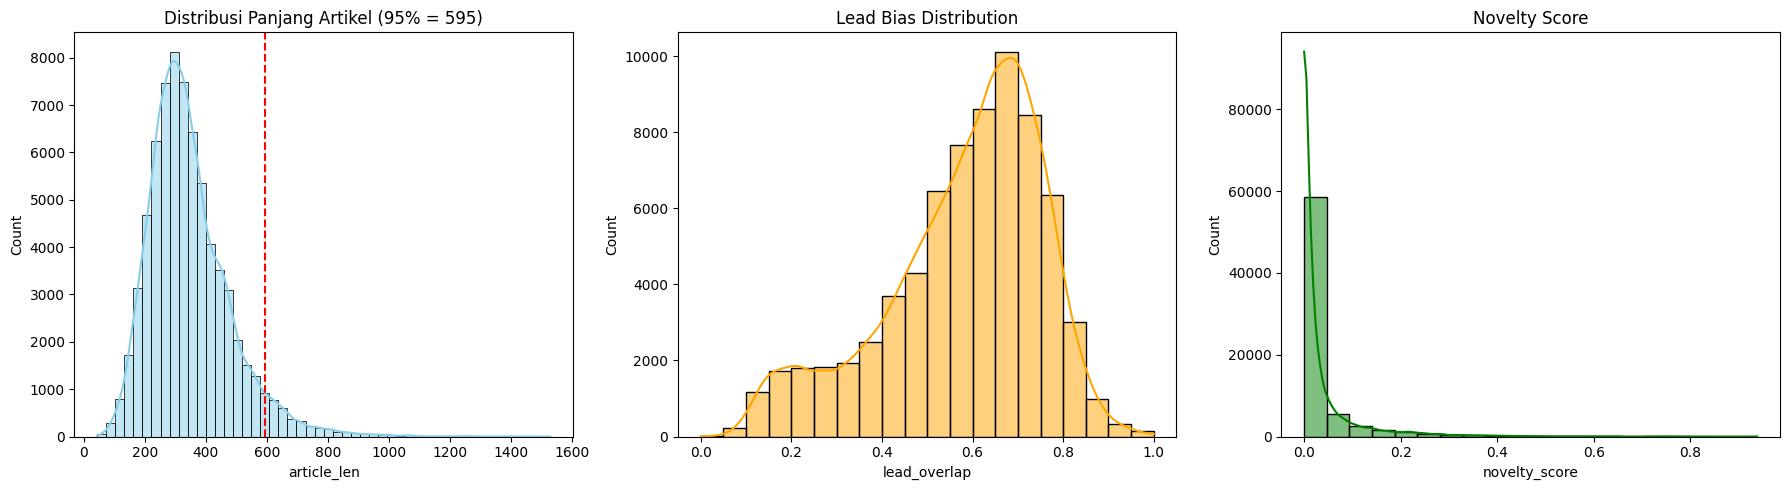

In [9]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['article_len'], bins=50, kde=True, color='skyblue')
plt.axvline(p95_article, color='red', linestyle='--')
plt.title(f'Distribusi Panjang Artikel (95% = {p95_article:.0f})')

plt.subplot(1, 3, 2)
sns.histplot(df['lead_overlap'], bins=20, kde=True, color='orange')
plt.title('Lead Bias Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['novelty_score'], bins=20, kde=True, color='green')
plt.title('Novelty Score')

plt.tight_layout()
plt.show()

In [10]:
duplicates = df[df.duplicated(subset=['text'], keep=False)]
duplicates_sorted = duplicates.sort_values(by='text')

print(f"Total rows involved in duplication: {len(duplicates_sorted)}")
print(f"Unique articles that have copies: {len(duplicates_sorted['text'].unique())}")

print("\n--- SAMPLE OF DUPLICATED ENTRIES (Top 4 rows) ---")
print(duplicates_sorted[['text', 'target']].head(4))

print("\n--- CHECKING A SPECIFIC DUPLICATE GROUP ---")
if len(duplicates_sorted) > 0:
    first_dup_text = duplicates_sorted.iloc[0]['text']
    specific_group = duplicates_sorted[duplicates_sorted['text'] == first_dup_text]
    print(f"Text content: {first_dup_text[:100]}...")
    print(f"Count of this specific article: {len(specific_group)}")
    print("Summaries for this article:")
    for i, summary in enumerate(specific_group['target']):
        print(f"  {i+1}. {summary[:100]}...")

Total rows involved in duplication: 71063
Unique articles that have copies: 19069

--- SAMPLE OF DUPLICATED ENTRIES (Top 4 rows) ---
                                                    text  \
28270  " Ada 1 persen rakyat yang mempunyai kekayaan ...   
37937  " Ada 1 persen rakyat yang mempunyai kekayaan ...   
10691  " Ada 1 persen rakyat yang mempunyai kekayaan ...   
64572  " Ada 1 persen rakyat yang mempunyai kekayaan ...   

                                                  target  
28270  Membayar pajak adalah kewajiban warga Negara I...  
37937  Membayar pajak adalah kewajiban warga Negara I...  
10691  Membayar pajak adalah kewajiban warga Negara I...  
64572  Membayar pajak adalah kewajiban warga Negara I...  

--- CHECKING A SPECIFIC DUPLICATE GROUP ---
Text content: " Ada 1 persen rakyat yang mempunyai kekayaan mencapai 50 persen dari rakyat Indonesia . Jika mereka...
Count of this specific article: 4
Summaries for this article:
  1. Membayar pajak adalah kewajiban warga Neg

In [11]:
print(f"Total Rows (Raw): {len(df)}")

df_clean = df.drop_duplicates(subset=['text'], keep='first')

df_clean = df_clean.reset_index(drop=True)

dataset['train'] = Dataset.from_pandas(df_clean)

print("="*30)
print("DATA CLEANING REPORT")
print("="*30)
print(f"Original Count : {len(df)}")
print(f"Clean Count    : {len(df_clean)}")
print(f"Trash Removed  : {len(df) - len(df_clean)} duplicates")
print("="*30)
print("Done.")

Total Rows (Raw): 71353
DATA CLEANING REPORT
Original Count : 71353
Clean Count    : 19359
Trash Removed  : 51994 duplicates
Done.


In [12]:
df_clean['article_len'] = df_clean['text'].apply(lambda x: len(str(x).split()))
df_clean['summary_len'] = df_clean['target'].apply(lambda x: len(str(x).split()))

p95_article = df_clean['article_len'].quantile(0.95)
p95_summary = df_clean['summary_len'].quantile(0.95)

print("="*40)
print("FINAL CONFIGURATION STATS (CLEAN DATA)")
print("="*40)
print(f"Total Unique Data: {len(df_clean)}")
print("-" * 20)
print(f"Article Length (95th): {p95_article:.2f} words")
print(f"Summary Length (95th): {p95_summary:.2f} words")
print("-" * 20)
print(f"Recommended max_input_length  : {int(p95_article * 1.3)}")
print(f"Recommended max_target_length : {int(p95_summary * 1.3)}")

FINAL CONFIGURATION STATS (CLEAN DATA)
Total Unique Data: 19359
--------------------
Article Length (95th): 624.00 words
Summary Length (95th): 78.00 words
--------------------
Recommended max_input_length  : 811
Recommended max_target_length : 101
